In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import h5py

In [6]:
def init_sudoku(n):
  N = n**2
  sudoku = np.random.randint(1, N+1, size=(N,N))
  return sudoku

In [7]:
def calculate_energy(sudoku):
  # size of sudoku and inside-square
  N = len(sudoku)
  n = int(np.sqrt(N))

  # init energy at level 0
  E = 0

  for i in range(N):
    line = sudoku[i, :]
    col = sudoku[:, i]
    r, c = divmod(i, n)
    block = sudoku[r*n:(r+1)*n, c*n:(c+1)*n]
    
    _, line_count = np.unique(line, return_counts=True)
    _, col_count = np.unique(col, return_counts=True)
    _, block_count = np.unique(block, return_counts=True)

    E += np.sum(line_count - 1) + np.sum(col_count - 1) + np.sum(block_count - 1)
  
  return E

In [8]:
def show_sudoku(sudoku):
  N = len(sudoku)
  n = int(np.sqrt(N))

  print(f'Sudoku of size {N}x{N}, current energy: {calculate_energy(sudoku)}\n')
  
  cell_width = len(str(np.max(sudoku))) + 2

  for i in range(n * n):
    # Horizontal block separator
    if i % n == 0 and i != 0:
        print("-" * ((n * n) * cell_width + (n - 1) * 3))

    row_str = []
    for j in range(n * n):

      # Vertical block separator
      if j % n == 0 and j != 0:
          row_str.append(" | ")

      # Center each number
      row_str.append(f"{sudoku[i, j]:^{cell_width}}")

    print("".join(row_str))


In [9]:
def draw_sudoku(sudoku, filename=None):
    """
    Draw a sudoku grid as an image.
    
    Parameters:
    - sudoku: NxN numpy array containing the sudoku values
    - filename: optional, path to save the image
    """
    N = len(sudoku)
    n = int(np.sqrt(N))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    
    # Remove axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Draw the numbers
    for i in range(N):
        for j in range(N):
            value = sudoku[i, j]
            ax.text(j + 0.5, N - i - 0.5, str(value),
                    ha='center', va='center', fontsize=20)
    
    # Draw thin lines for cells
    for i in range(N + 1):
        lw = 0.5
        ax.axhline(i, color='black', linewidth=lw)
        ax.axvline(i, color='black', linewidth=lw)
    
    # Draw thick lines for blocks
    for i in range(n + 1):
        lw = 3
        ax.axhline(i * n, color='black', linewidth=lw)
        ax.axvline(i * n, color='black', linewidth=lw)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved to {filename}")
    
    plt.show()

77
285
Saved to ../figures/sudoku/grid/9.png


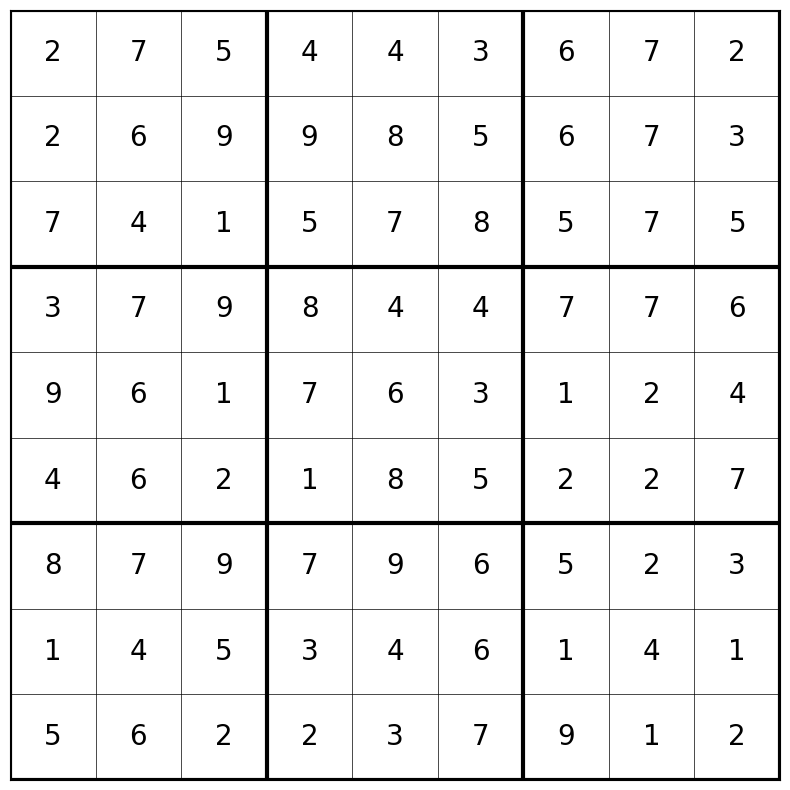

Saved to ../figures/sudoku/grid/16.png


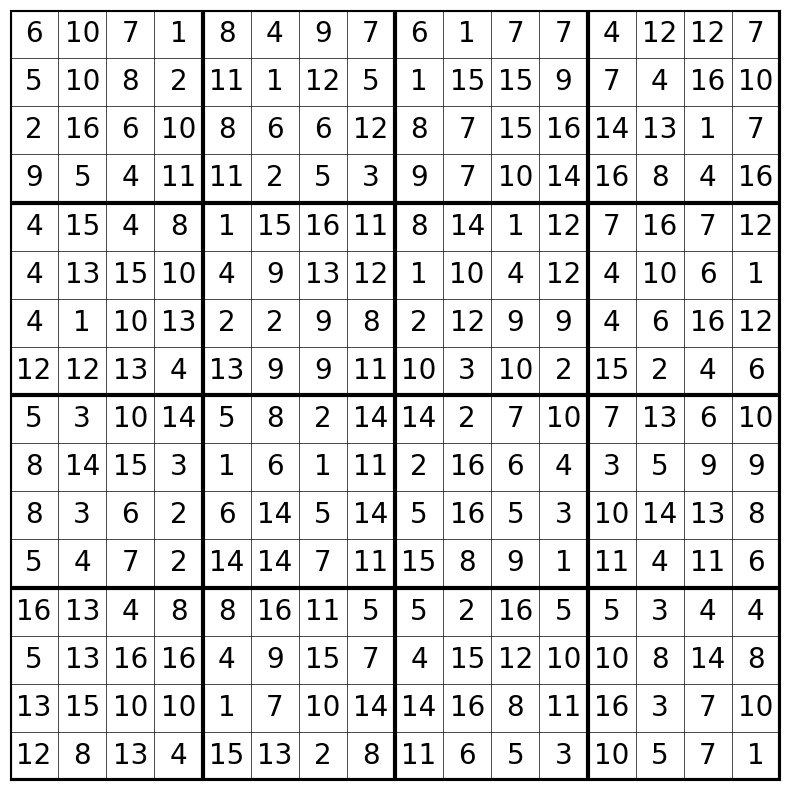

In [10]:
sudoku1, sudoku2 = init_sudoku(3), init_sudoku(4)

print(calculate_energy(sudoku1))
print(calculate_energy(sudoku2))
draw_sudoku(sudoku1, filename='../figures/sudoku/grid/9.png')
draw_sudoku(sudoku2, filename='../figures/sudoku/grid/16.png')

In [11]:
def metropolis(sudoku, N, T, nb_iter):
  E = calculate_energy(sudoku)

  # Track energy evolution
  Es = [E]

  for _ in range(nb_iter):
    # A site is chosen at random
    x = np.random.randint(0, N)
    y = np.random.randint(0, N)

    # Change the site
    spin = sudoku[x][y]

    new_spin = random.randint(1, N)
    while new_spin == spin:
      new_spin = random.randint(1, N)

    sudoku[x][y] = new_spin

    # Compute the change in energy if we flip that site
    dE = calculate_energy(sudoku) - Es[-1]
    # Transition probability
    p = np.exp(-dE/T)

    # If the energy decreases, the site flips
    if dE <= 0:
      E += dE
    # If the energy increases, the site flips with probability p.
    elif np.random.rand() <= p:
      E += dE
    else:
      sudoku[x][y] = spin

    Es.append(E)

  return sudoku, Es

Sudoku of size 16x16, current energy: 265

 7   4   14  1   |  6   2   1   13  |  1   13  15  6   |  2   15  14  8  
 2   6   5   12  |  14  16  15  10  |  13  14  4   13  |  16  7   6   9  
 11  11  5   8   |  12  15  1   14  |  11  5   2   16  |  11  6   8   13 
 12  10  7   6   |  7   6   9   10  |  7   10  14  10  |  12  14  5   4  
-------------------------------------------------------------------------
 8   11  10  13  |  3   11  6   11  |  13  1   11  15  |  16  4   5   4  
 16  13  5   6   |  16  12  12  4   |  3   9   2   3   |  11  3   9   1  
 13  9   8   7   |  5   14  13  16  |  15  5   14  15  |  16  12  11  12 
 6   4   3   2   |  16  4   10  10  |  12  12  12  7   |  10  5   10  9  
-------------------------------------------------------------------------
 12  3   13  3   |  2   8   6   9   |  4   5   8   4   |  14  6   13  9  
 13  7   16  12  |  12  3   16  1   |  2   9   16  2   |  4   12  4   5  
 14  8   11  6   |  7   11  8   14  |  12  11  5   8   |  8   9   7  

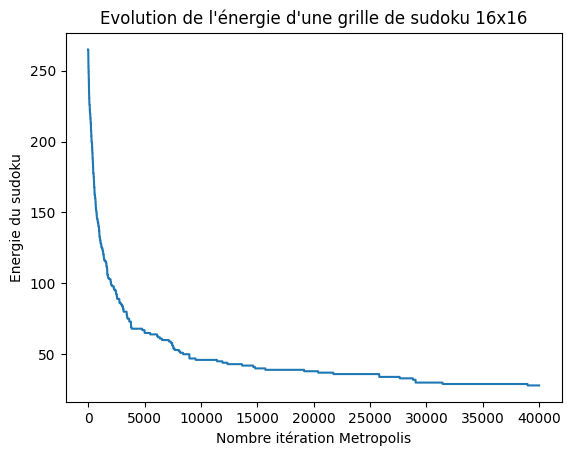

In [12]:
n = 4
N = n**2
T = 0.01
# Metropolis number of iteration
nb_iter = 40000

sudoku = init_sudoku(n)
show_sudoku(sudoku)

t = np.arange(nb_iter + 1) # +1 due to init configuration
sudoku, Es = metropolis(sudoku, N, T, nb_iter)
show_sudoku(sudoku)

plt.plot(t, Es)

plt.xlabel('Nombre itération Metropolis')
plt.ylabel('Energie du sudoku')
plt.title(f'Evolution de l\'énergie d\'une grille de sudoku {N}x{N}')
plt.show()

/var/folders/3_/wvrjtxj15lz0gq4qrprc2sk80000gn/T/ipykernel_5870/3052060147.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  p = np.exp(-dE/T)
/var/folders/3_/wvrjtxj15lz0gq4qrprc2sk80000gn/T/ipykernel_5870/3052060147.py:24: RuntimeWarning: invalid value encountered in scalar divide
  p = np.exp(-dE/T)


Mean of the convergent energy: 93.7


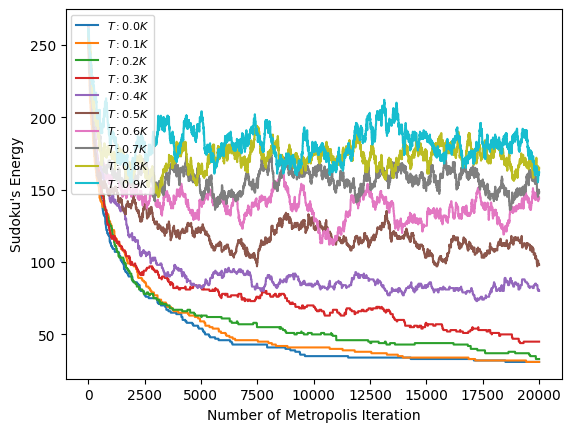

In [13]:
n = 4
N = n**2
T = 0.01
# Metropolis number of iteration
nb_iter = 20000

Es_final = []
sudoku_init = init_sudoku(n)  # Sudoku de référence
for T in np.arange(10)*0.1:
  t = np.arange(nb_iter + 1) # +1 due to init configuration
  sudoku = sudoku_init.copy()  # Copie fraîche à chaque itération
  _, Es = metropolis(sudoku, N, T, nb_iter)

  Es_final.append(Es[-1])

  plt.plot(t, Es, label=f'$T: {round(T, 3)}K$')

Es_final = np.array(Es_final)
print(f'Mean of the convergent energy: {Es_final.mean()}')
plt.xlabel('Number of Metropolis Iteration')
plt.ylabel('Sudoku\'s Energy')
#plt.title(f'Evolution de l\'énergie d\'une grille de sudoku {N}x{N}')
plt.savefig('../figures/sudoku/energy/9.png', bbox_inches='tight')
plt.legend(loc='upper left', fontsize=8)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

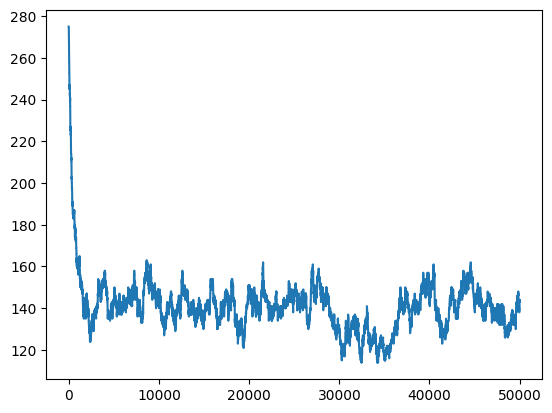

In [14]:
n = 4
sudo = init_sudoku(n)
_, Es = metropolis(sudo, n*n, 0.6, 50000)
plt.plot(np.arange(len(Es)), Es)
plt.show

N=3 : 9
N = 4 : 61.475

Données chargées:
  Grille: 25x25
  Températures: 1e-05 à 1.0
  Itérations Metropolis: 100000
  Nombre de points Sensibilité: 5000

Température de transition: T_c ≈ 0.0000 K
Valeur maximale de la sensibilité: 2.6247e+05


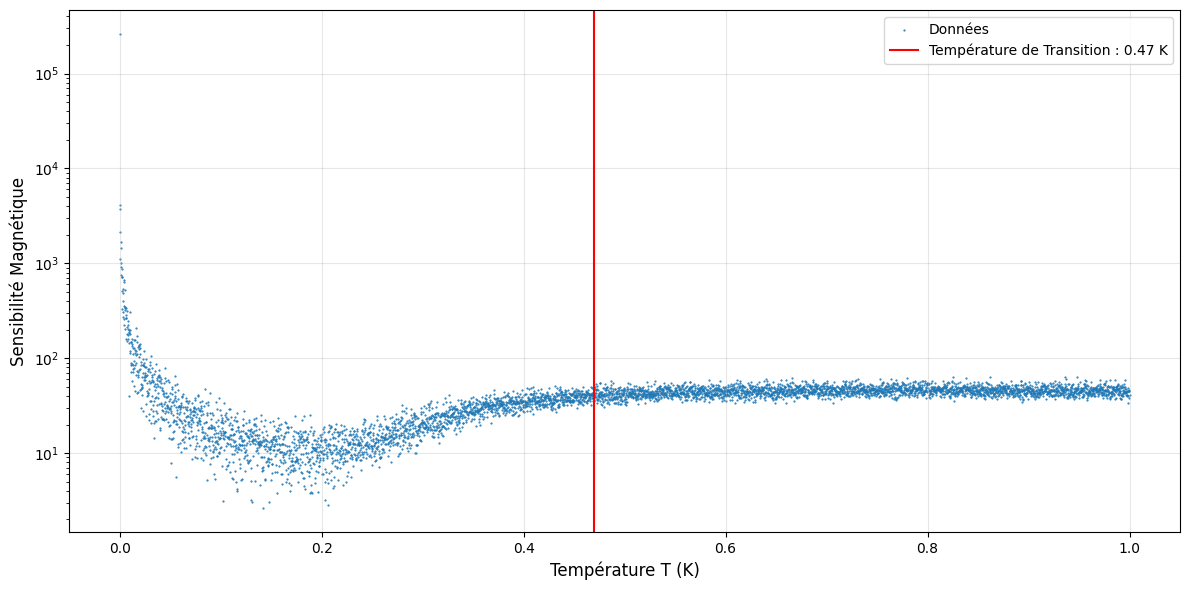

In [20]:
show_sensibilite('25-magnetic.h5', 0.47)